# 1. Combining

In [ ]:
import csv
from pathlib import Path
import pandas as pd
import numpy as np

BASE = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Google Trends Data + Extracter").exists())
GT   = BASE / "Google Trends Data + Extracter"
RAW  = GT / "raw"
PLAN = GT / "trends_pull_urls.csv"

assert PLAN.exists(), f"plan not found at {PLAN}"
print(f"{len(list(RAW.glob('*.csv')))} files in raw/")     # 68

STATES = [
 "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut",
 "Delaware","District of Columbia","Florida","Georgia","Hawaii","Idaho","Illinois",
 "Indiana","Iowa","Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts",
 "Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska","Nevada",
 "New Hampshire","New Jersey","New Mexico","New York","North Carolina","North Dakota",
 "Ohio","Oklahoma","Oregon","Pennsylvania","Rhode Island","South Carolina",
 "South Dakota","Tennessee","Texas","Utah","Vermont","Virginia","Washington",
 "West Virginia","Wisconsin","Wyoming"]

takes one Google Trends "Interest by subregion" CSV and returns a clean pandas Series of 51 state values.

essentially:
messy CSV → find the header → parse rows → clean values → align to 51 states

In [7]:
def read_geomap(path):
    """One Trends 'Interest by subregion' CSV -> Series indexed by the 51 states."""
    lines = [l for l in Path(path).read_text(encoding="utf-8-sig").splitlines() if l.strip()]
    h = next((i for i, l in enumerate(lines)
              if l.split(",")[0].strip() in ("Region", "Country")), None)
    if h is None:
        raise ValueError(f"{Path(path).name}: no 'Region' header — Interest-over-time file?")

    rows = list(csv.reader(lines[h:]))
    header, body = rows[0], [r for r in rows[1:] if r and r[0].strip()]
    if len(header) - 1 > 1:
        raise ValueError(f"{Path(path).name}: compared breakdown (rows sum to 100%), "
                         "not a single-term export")

    def num(x):
        x = x.strip().replace("%", "")
        if x in ("", "N/A"):  return np.nan
        if x.startswith("<"): return 0.5          # Trends' "<1"
        try:    return float(x)
        except ValueError: return np.nan

    return pd.Series({r[0].strip(): num(r[1]) for r in body},
                     dtype=float).reindex(STATES)

loads all 68 Trends CSVs, stacks them into one long table, then reshapes to one row per state-year.

In [8]:
plan = pd.read_csv(PLAN)

recs = []
for r in plan.itertuples():
    s = read_geomap(RAW / r.save_as)
    recs.append(pd.DataFrame({"state": s.index, "year": r.year,
                              "category": r.category, "term_id": r.term_id,
                              "term": r.term, "rsv": s.values}))
long = pd.concat(recs, ignore_index=True)      # keep this — z-scoring is easier long

col_order = (plan.sort_values(["category", "order"])
                 .drop_duplicates("term_id").term_id.tolist())

wide = (long.pivot_table(index=["state", "year"], columns="term_id", values="rsv")
            .reindex(columns=col_order)
            .reset_index()
            .sort_values(["state", "year"]))
wide.columns.name = None

print(wide.shape)          # (204, 19)
wide.head()

(204, 19)


,state,year,polling_place,where_to_vote,register_to_vote,sample_ballot,how_to_vote,us_pres_election,year_election,election_day,presidential_debate,electoral_college,absentee_ballot,early_voting,vote_by_mail,voter_id,ballot_drop_box,nominee_dem,nominee_rep
0,Alabama,2012,31.0,61.0,79.0,68.0,100.0,91.0,88.0,56.0,48.0,92.0,78.0,19.0,NaN,15.0,NaN,81.0,59.0
1,Alabama,2016,46.0,53.0,70.0,46.0,74.0,61.0,73.0,50.0,64.0,82.0,64.0,14.0,4.0,53.0,NaN,71.0,77.0
2,Alabama,2020,49.0,51.0,66.0,82.0,92.0,67.0,72.0,42.0,65.0,45.0,75.0,24.0,28.0,40.0,4.0,61.0,74.0
3,Alabama,2024,40.0,88.0,81.0,34.0,100.0,43.0,67.0,57.0,52.0,53.0,49.0,21.0,14.0,61.0,NaN,51.0,75.0
4,Alaska,2012,25.0,31.0,34.0,10.0,38.0,87.0,76.0,45.0,69.0,76.0,43.0,20.0,NaN,14.0,NaN,52.0,45.0


output file (comment out if not needed)

In [ ]:
# OUT = GT / "out"
# OUT.mkdir(exist_ok=True)
# XLSX = OUT / "trends_combined.xlsx"

# # lookup sheet: which category / search string / form each column came from
# key = (plan.drop_duplicates("term_id")[["category", "term_id", "term", "form"]]
#            .set_index("term_id").reindex(col_order).reset_index())

# with pd.ExcelWriter(XLSX, engine="openpyxl") as xl:
#     wide.to_excel(xl, sheet_name="wide",     index=False, freeze_panes=(1, 2))
#     long.to_excel(xl, sheet_name="long",     index=False, freeze_panes=(1, 0))
#     key .to_excel(xl, sheet_name="term_key", index=False)

#     # readable column widths
#     for sheet, df in [("wide", wide), ("long", long), ("term_key", key)]:
#         ws = xl.sheets[sheet]
#         for i, c in enumerate(df.columns, 1):
#             w = max(len(str(c)), int(df[c].astype(str).str.len().max() or 0))
#             ws.column_dimensions[ws.cell(1, i).column_letter].width = min(max(w + 2, 9), 40)

# print(f"wrote {XLSX}  ({XLSX.stat().st_size/1024:.0f} KB)")

wrote c:\Users\Nicolas\OneDrive\ADMU\Thesis\US Elections\out\trends_combined.xlsx  (112 KB)


In [9]:
print(wide.groupby("year").size())                    # 51 each
print(wide.isna().sum()[lambda s: s > 0])             # where Google returned nothing

year
2012    51
2016    51
2020    51
2024    51
dtype: int64
polling_place        2
sample_ballot        1
vote_by_mail        25
voter_id            11
ballot_drop_box    104
dtype: int64


creating categories

In [11]:
DROP      = ["us_pres_election", "ballot_drop_box", "vote_by_mail"]  # failed screening
MIN_TERMS = 2                                                        # else NaN

d = long[~long.term_id.isin(DROP)].copy()
d["rsv"] = d.rsv.fillna(0)

g = d.groupby(["term_id", "year"])["rsv"]
d["z"] = (d.rsv - g.transform("mean")) / g.transform("std")

agg = d.groupby(["state", "year", "category"])["z"].agg(["mean", "count"])
agg.loc[agg["count"] < MIN_TERMS, "mean"] = np.nan

cats = agg["mean"].unstack("category").reset_index()
cats.columns.name = None
cats = cats.rename(columns={"C1_logistics": "logistics_index",
                            "C2_salience":  "salience_index",
                            "C3_process":   "process_index",
                            "C4_candidates":"candidate_index"})

print(cats.shape)          # (204, 6)
cats.head()

(204, 6)


,state,year,logistics_index,salience_index,process_index,candidate_index
0,Alabama,2012,1.417872,0.294415,0.160596,0.253194
1,Alabama,2016,0.511036,-0.455532,0.124113,-0.446398
2,Alabama,2020,0.551567,-1.147425,0.202027,-0.562270
3,Alabama,2024,0.939912,-0.634807,0.009782,0.102074
4,Alaska,2012,-1.319171,-0.166818,-0.396500,-1.716017


dependent vars

In [13]:
TURN = BASE / "Official Turnout Data"
DB   = TURN / "USA Voter Turnout DB.csv"

PRES = [2004, 2008, 2012, 2016, 2020, 2024]     # 2004/2008 only to build turnout_prev

raw = pd.read_csv(DB)
raw.columns = [str(c).strip() for c in raw.columns]

turnout = (raw.melt(id_vars="State", var_name="year", value_name="raw")
              .rename(columns={"State": "state"}))

turnout["state"]   = turnout.state.astype(str).str.strip()
turnout["year"]    = pd.to_numeric(turnout.year, errors="coerce")
turnout["turnout"] = pd.to_numeric(
    turnout.raw.astype(str).str.replace("%", "", regex=False).str.strip(),
    errors="coerce")                              # "58.80%" -> 58.8 ; "N/A" -> NaN

turnout = (turnout[turnout.state.isin(STATES) & turnout.year.isin(PRES)]
             [["state", "year", "turnout"]]
             .sort_values(["state", "year"])
             .reset_index(drop=True))

turnout["turnout_prev"] = turnout.groupby("state")["turnout"].shift(1)

target = turnout[turnout.year >= 2012].reset_index(drop=True)

print(target.shape)                               # expect (204, 4)
print(target.groupby("year").size())              # expect 51 each
print("\nmissing:")
print(target[target.turnout.isna() | target.turnout_prev.isna()])
target.head(12)

(204, 4)
year
2012    51
2016    51
2020    51
2024    51
dtype: int64

missing:
             state  year  turnout  turnout_prev
0          Alabama  2012      NaN          61.0
1          Alabama  2016     59.1           NaN
24     Connecticut  2012     61.4           NaN
28        Delaware  2012      NaN          65.8
29        Delaware  2016     64.4           NaN
96     Mississippi  2012      NaN           NaN
97     Mississippi  2016      NaN           NaN
98     Mississippi  2020     60.4           NaN
100       Missouri  2012      NaN          68.2
101       Missouri  2016     64.2           NaN
144       Oklahoma  2012      NaN          56.3
145       Oklahoma  2016      NaN           NaN
146       Oklahoma  2020     55.3           NaN
152   Pennsylvania  2012      NaN          64.2
153   Pennsylvania  2016      NaN           NaN
154   Pennsylvania  2020     70.1           NaN
156   Rhode Island  2012      NaN          62.3
157   Rhode Island  2016     59.7           NaN
172    

,state,year,turnout,turnout_prev
0,Alabama,2012,NaN,61.0
1,Alabama,2016,59.1,NaN
2,Alabama,2020,61.8,59.1
3,Alabama,2024,58.8,61.8
4,Alaska,2012,58.9,68.3
5,Alaska,2016,61.5,58.9
6,Alaska,2020,68.4,61.5
7,Alaska,2024,63.7,68.4
8,Arizona,2012,53.0,57.4
9,Arizona,2016,56.1,53.0


# 2. Testing Variable Strength

In [14]:
panel = (target.merge(cats, on=["state", "year"], how="inner")
               .sort_values(["state", "year"])
               .reset_index(drop=True))

TRENDS = ["logistics_index", "salience_index", "process_index", "candidate_index"]
FEATS  = ["turnout_prev"] + TRENDS

print(panel.shape)                                   # expect (204, 8)
print(panel.groupby("year").size())                  # expect 51 each
print("\nrows lost to missing:",
      len(panel) - len(panel.dropna(subset=["turnout"] + FEATS)))

model_df = panel.dropna(subset=["turnout"] + FEATS).reset_index(drop=True)
print("usable rows:", len(model_df))

(204, 8)
year
2012    51
2016    51
2020    51
2024    51
dtype: int64

rows lost to missing: 27
usable rows: 177


In [15]:
corr = model_df[["turnout"] + FEATS].corr()

print("raw correlation with turnout:")
print(corr["turnout"].drop("turnout").sort_values(ascending=False).round(3).to_string())

print("\ncorrelations between predictors:")
print(corr.loc[FEATS, FEATS].round(2).to_string())

raw correlation with turnout:
turnout_prev       0.776
candidate_index    0.369
salience_index     0.250
process_index      0.067
logistics_index   -0.065

correlations between predictors:
                 turnout_prev  logistics_index  salience_index  process_index  candidate_index
turnout_prev             1.00            -0.06            0.20           0.06             0.32
logistics_index         -0.06             1.00           -0.08           0.34             0.10
salience_index           0.20            -0.08            1.00           0.12             0.29
process_index            0.06             0.34            0.12           1.00             0.34
candidate_index          0.32             0.10            0.29           0.34             1.00


In [16]:
def residualise(x, ctrl):
    """Remove the linear effect of ctrl from x."""
    X = np.column_stack([np.ones(len(ctrl)), ctrl])
    b, *_ = np.linalg.lstsq(X, x, rcond=None)
    return x - X @ b

def partial_corr(df, xcol, ycol, ctrl_cols):
    C = df[ctrl_cols].values
    rx = residualise(df[xcol].values, C)
    ry = residualise(df[ycol].values, C)
    return np.corrcoef(rx, ry)[0, 1]

print(f"{'index':<20}{'raw r':>9}{'partial r':>12}")
for f in TRENDS:
    raw = model_df[f].corr(model_df.turnout)
    par = partial_corr(model_df, f, "turnout", ["turnout_prev"])
    print(f"{f:<20}{raw:>9.3f}{par:>12.3f}")

index                   raw r   partial r
logistics_index        -0.065      -0.029
salience_index          0.250       0.148
process_index           0.067       0.027
candidate_index         0.369       0.203


In [17]:
print(f"{'index':<20}" + "".join(f"{y:>9}" for y in sorted(model_df.year.unique())))
for f in TRENDS:
    cells = []
    for y in sorted(model_df.year.unique()):
        g = model_df[model_df.year == y]
        cells.append(partial_corr(g, f, "turnout", ["turnout_prev"]) if len(g) > 5 else np.nan)
    print(f"{f:<20}" + "".join(f"{c:>9.2f}" for c in cells))

index                    2012     2016     2020     2024
logistics_index          0.20    -0.22    -0.31     0.30
salience_index           0.21     0.16     0.16     0.14
process_index            0.31    -0.32    -0.27     0.41
candidate_index          0.42     0.23    -0.02     0.60


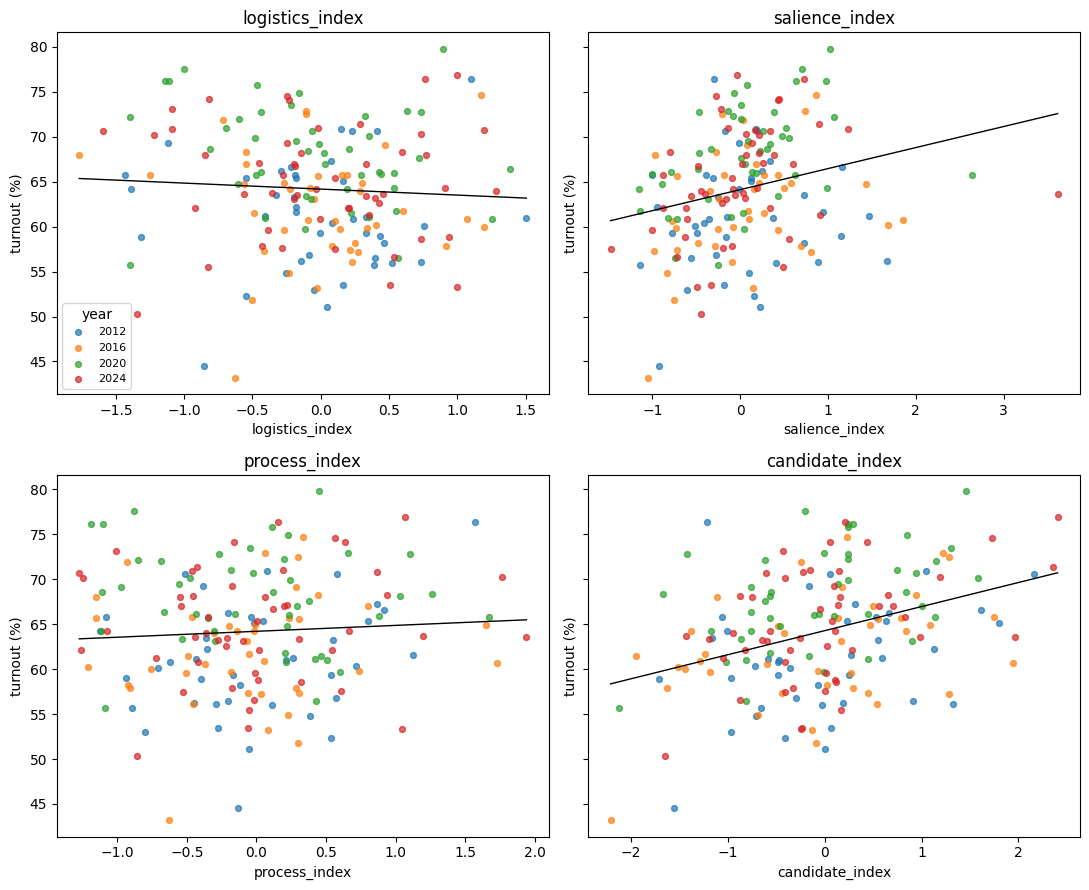

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)
for ax, f in zip(axes.ravel(), TRENDS):
    for y, g in model_df.groupby("year"):
        ax.scatter(g[f], g.turnout, s=18, alpha=.7, label=str(y))
    b = np.polyfit(model_df[f], model_df.turnout, 1)
    xs = np.linspace(model_df[f].min(), model_df[f].max(), 50)
    ax.plot(xs, np.polyval(b, xs), color="black", lw=1)
    ax.set_xlabel(f); ax.set_ylabel("turnout (%)"); ax.set_title(f)
axes[0, 0].legend(title="year", fontsize=8)
plt.tight_layout(); plt.show()

In [19]:
def fit_ols(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return b

def predict(b, X):
    return np.column_stack([np.ones(len(X)), X]) @ b

def scores(y_true, y_pred):
    e = y_true - y_pred
    return dict(MAE=np.abs(e).mean(),
                RMSE=np.sqrt((e**2).mean()),
                R2=1 - (e**2).sum() / ((y_true - y_true.mean())**2).sum())

In [20]:
tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]

MODELS = {
    "B0  national mean":            [],
    "B1  turnout_prev":             ["turnout_prev"],
    "B2  + logistics":              ["turnout_prev", "logistics_index"],
    "B3  + salience":               ["turnout_prev", "salience_index"],
    "B4  + process":                ["turnout_prev", "process_index"],
    "B5  + candidate":              ["turnout_prev", "candidate_index"],
    "B6  + all four":               FEATS,
    "B7  Trends only (no history)": TRENDS,
}

print(f"train {sorted(tr.year.unique())} (n={len(tr)}) -> test 2024 (n={len(te)})\n")
print(f"{'model':<32}{'MAE':>7}{'RMSE':>8}{'R2':>8}{'dMAE':>8}")
base = None
for name, cols in MODELS.items():
    if not cols:
        pred = np.full(len(te), tr.turnout.mean())
    else:
        pred = predict(fit_ols(tr[cols].values, tr.turnout.values), te[cols].values)
    s = scores(te.turnout.values, pred)
    if name.startswith("B1"): base = s["MAE"]
    d = "" if base is None else f"{s['MAE'] - base:+8.3f}"
    print(f"{name:<32}{s['MAE']:>7.3f}{s['RMSE']:>8.3f}{s['R2']:>8.3f}{d}")

train [np.int64(2012), np.int64(2016), np.int64(2020)] (n=126) -> test 2024 (n=51)

model                               MAE    RMSE      R2    dMAE
B0  national mean                 4.939   6.195  -0.030
B1  turnout_prev                  3.442   3.876   0.597  +0.000
B2  + logistics                   3.442   3.905   0.591  -0.000
B3  + salience                    3.336   3.760   0.621  -0.106
B4  + process                     3.453   3.905   0.591  +0.012
B5  + candidate                   3.181   3.648   0.643  -0.261
B6  + all four                    3.140   3.631   0.646  -0.302
B7  Trends only (no history)      4.460   5.511   0.185  +1.019


In [21]:
FOLDS = [([2012, 2016],       2020),
         ([2012, 2016, 2020], 2024)]

print(f"{'model':<32}" + "".join(f"{'test '+str(t):>13}" for _, t in FOLDS) + f"{'mean':>9}")
for name, cols in MODELS.items():
    maes = []
    for train_years, test_year in FOLDS:
        a = model_df[model_df.year.isin(train_years)]
        b = model_df[model_df.year == test_year]
        pred = (np.full(len(b), a.turnout.mean()) if not cols
                else predict(fit_ols(a[cols].values, a.turnout.values), b[cols].values))
        maes.append(scores(b.turnout.values, pred)["MAE"])
    print(f"{name:<32}" + "".join(f"{m:>13.3f}" for m in maes) + f"{np.mean(maes):>9.3f}")

model                               test 2020    test 2024     mean
B0  national mean                       6.980        4.939    5.960
B1  turnout_prev                        6.974        3.442    5.208
B2  + logistics                         6.977        3.442    5.209
B3  + salience                          6.950        3.336    5.143
B4  + process                           6.970        3.453    5.212
B5  + candidate                         6.948        3.181    5.064
B6  + all four                          6.941        3.140    5.040
B7  Trends only (no history)            6.708        4.460    5.584


In [22]:
rng = np.random.default_rng(0)
model_df["pure_noise"] = rng.normal(size=len(model_df))   # control: means nothing
COLS = FEATS + ["pure_noise"]

tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]
b  = fit_ols(tr[COLS].values, tr.turnout.values)
Xte, yte = te[COLS].values, te.turnout.values
base = np.abs(yte - predict(b, Xte)).mean()

print(f"baseline test MAE = {base:.3f} pp\n")
print(f"{'feature':<20}{'MAE rise':>10}{'sd':>8}")
for i, f in enumerate(COLS):
    ds = []
    for _ in range(100):
        Xp = Xte.copy()
        Xp[:, i] = rng.permutation(Xp[:, i])
        ds.append(np.abs(yte - predict(b, Xp)).mean() - base)
    print(f"{f:<20}{np.mean(ds):>10.3f}{np.std(ds):>8.3f}")

baseline test MAE = 3.129 pp

feature               MAE rise      sd
turnout_prev             3.113   0.450
logistics_index         -0.016   0.015
salience_index          -0.008   0.027
process_index           -0.032   0.015
candidate_index          0.170   0.041
pure_noise               0.016   0.015
